In [2]:
from pymongo import MongoClient
from pyspark.sql import SparkSession

client = MongoClient("mongodb://mongodb:27017/")
db = client["proyecto_bigdata"]
coleccion = db["datos_scraping"]

datos = list(coleccion.find())

for d in datos:
    d["_id"] = str(d["_id"])

spark = SparkSession.builder.appName("AnalisisAutos").getOrCreate()

df = spark.createDataFrame(datos)

df.show(5, truncate=False)

+------------------------+----+---------------+-----------+-------------------+-----------+-------+---------+---------------+-----------+--------------------------------------------------------------+
|_id                     |anio|ciudad_o_comuna|combustible|fecha_captura      |kilometraje|marca  |modelo   |nombre         |precio     |url                                                           |
+------------------------+----+---------------+-----------+-------------------+-----------+-------+---------+---------------+-----------+--------------------------------------------------------------+
|69eeb708c0a04fa740ad630e|2023|Huechuraba     |Gasolina   |2026-04-27 00:00:18|35.296 Km  |Jeep   |Commander|Javiera Pizarro|$23.090.000|https://www.clicar.cl/marcas/jeep/usado/jeep-commander-7861   |
|69eeb708c0a04fa740ad630f|2023|Huechuraba     |Diesel     |2026-04-27 00:00:18|75.572 Km  |Peugeot|3008     |Javiera Pizarro|$16.190.000|https://www.clicar.cl/marcas/peugeot/usado/peugeot-3008-731

In [3]:
from pyspark.sql.functions import col, regexp_replace

df = df.withColumn(
    "precio_num",
    regexp_replace(col("precio"), "[^0-9]", "").cast("int")
)

df.select("precio", "precio_num").show(5)

+-----------+----------+
|     precio|precio_num|
+-----------+----------+
|$23.090.000|  23090000|
|$16.190.000|  16190000|
|$60.490.000|  60490000|
|$15.490.000|  15490000|
|$33.390.000|  33390000|
+-----------+----------+
only showing top 5 rows



In [4]:
df.selectExpr("avg(precio_num) as promedio_precio").show()

+--------------------+
|     promedio_precio|
+--------------------+
|2.2302916666666668E7|
+--------------------+



In [5]:
df.groupBy("marca").count().show()

+----------+-----+
|     marca|count|
+----------+-----+
|   Peugeot|   10|
|      Jeep|    7|
|       Kia|   10|
| Chevrolet|   29|
|     Volvo|    4|
|   Changan|    4|
|     Honda|    6|
|      Audi|    6|
|   Renault|    3|
|     Chery|   14|
|     Maxus|    5|
|    Nissan|   29|
|      Ford|   18|
|    Subaru|   11|
|    Jaguar|    2|
|    Jetour|    3|
|     Kaiyi|    2|
| Ssangyong|    6|
|Land Rover|    4|
|   Porsche|    2|
+----------+-----+
only showing top 20 rows



In [6]:
df.groupBy("combustible").count().show()

+---------------+-----+
|    combustible|count|
+---------------+-----+
|         Diesel|   28|
|        Híbrido|    4|
|       Gasolina|  205|
|      Eléctrico|    2|
|No especificado|    1|
+---------------+-----+



In [13]:
from pyspark.sql.functions import col

top_autos = df.orderBy(col("precio_num").desc()).limit(10)

top_autos.select("marca", "modelo", "precio_num").show()

+----------+---------+----------+
|     marca|   modelo|precio_num|
+----------+---------+----------+
|   Porsche|    Macan|  83390000|
|   Porsche|    Macan|  82590000|
|Land Rover| Defender|  70890000|
| Chevrolet|Silverado|  64290000|
|      Ford|    F 150|  61790000|
|      Ford|    F 150|  60490000|
|      Ford|    F 150|  60290000|
| Chevrolet|Silverado|  58190000|
| Chevrolet|Silverado|  58190000|
|    Jaguar|   F Pace|  56690000|
+----------+---------+----------+



In [14]:
pdf_top = top_autos.toPandas()

In [15]:
pdf_top["auto"] = pdf_top["marca"] + " " + pdf_top["modelo"]

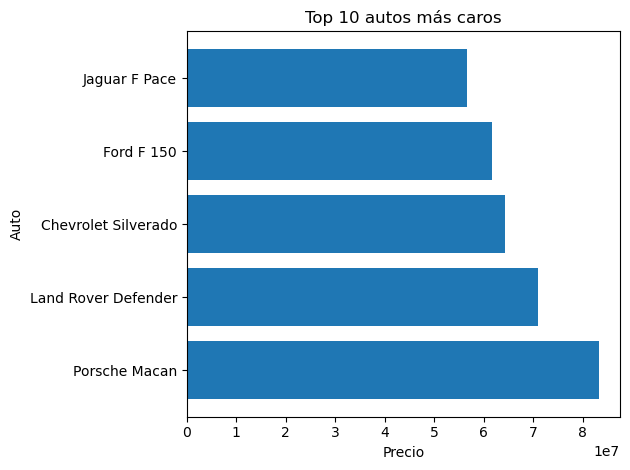

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(pdf_top["auto"], pdf_top["precio_num"])

plt.title("Top 10 autos más caros")
plt.xlabel("Precio")
plt.ylabel("Auto")

plt.tight_layout()
plt.show()